# Cortical development, lineage flow, and ERBB4 perturbation

This tutorial uses the human cortical development example to connect three common downstream questions: what happens between observed time points, how cell states flow between lineages, and how an ERBB4 perturbation changes trajectories and terminal composition.


## Workflow

1. Reconstruct dense-time RNA–ATAC dynamics.
2. Plot observed and interpolated developmental states.
3. Build a lineage Sankey from model trajectories and classifier labels.
4. Perturb ERBB4 and compare trajectories and terminal fates.


In [ ]:
from pathlib import Path
import json

from mofi_notebook import setup_notebook, suppress_live_plot_output

# Run Jupyter from the repository root. The helper selects CUDA when available.
ROOT, DEVICE, _ = setup_notebook()
print(f"Repository: {ROOT}")
print(f"Device: {DEVICE}")


## 1. Reconstruct dense-time dynamics


In [ ]:
from CytoBridge.reproducibility import require_paper_data, run_real_downstream

DATASET = "hc_author5"
paths = require_paper_data(DATASET, ROOT)
paper_output = ROOT / "results" / "figure_6_paper"

with suppress_live_plot_output():
    downstream = run_real_downstream(
        DATASET,
        output_dir=paper_output,
        selected_figures=[],
        device=DEVICE,
        sample_max_cells=None,
        reuse_cache=True,
        repo_root=ROOT,
    )
run_dir = Path(downstream["run_dir"])
run_dir


## 2. Display observed and interpolated time slices

Time slices are rendered from the resolved dataset configuration. Changing the requested time grid in that configuration is enough to inspect additional unobserved times.


In [ ]:
from CytoBridge.manuscript import render_hc_time_slices
from CytoBridge.reproducibility import write_resolved_analysis_config

local_cfg = write_resolved_analysis_config(
    DATASET,
    output_dir=paper_output,
    config_path=ROOT / "results" / "figure6_resolved.yaml",
    device=DEVICE,
    repo_root=ROOT,
)
with suppress_live_plot_output():
    time_slice_dir = render_hc_time_slices(
        config_path=local_cfg,
        output_dir=run_dir / "figures" / "time_slices",
        repo_root=ROOT,
    )
time_slice_dir


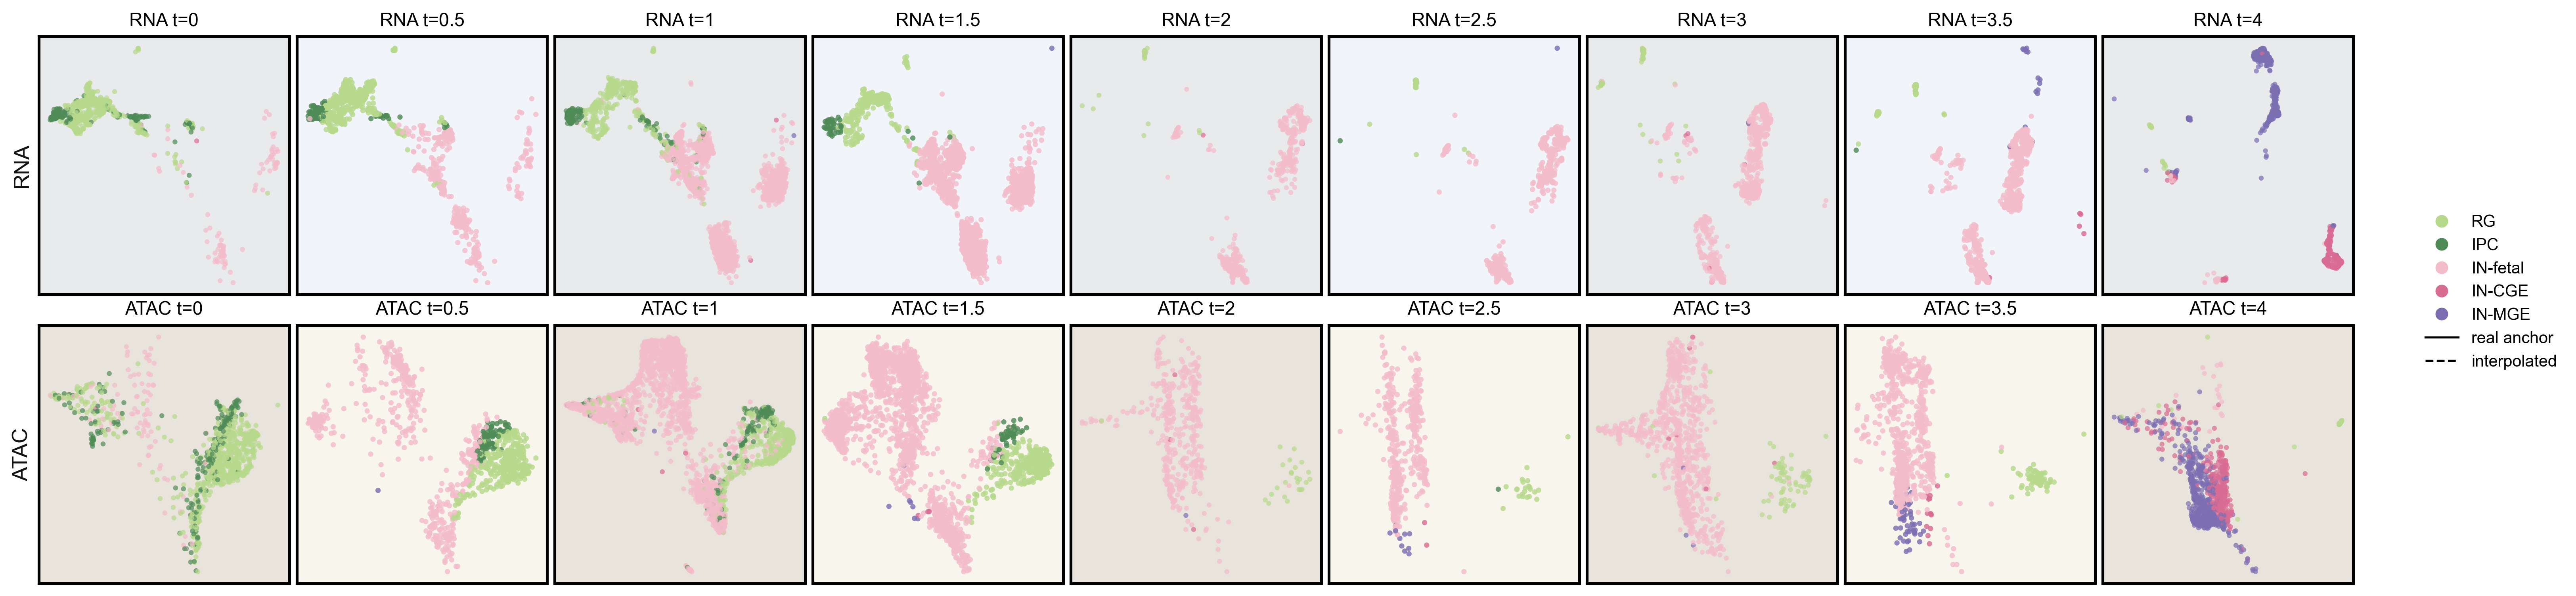

In [ ]:
from mofi_notebook import show_paper_panel
show_paper_panel(run_dir / "figures" / "time_slices" / "author5_time_slice_panels_umap.png")


## 3. Build the lineage Sankey

Each Sankey link aggregates model trajectories assigned to a cell type at consecutive times. The function also saves the transition table as CSV, which is the best starting point for a custom lineage plot.


In [ ]:
from CytoBridge.manuscript import render_hc_lineage

with suppress_live_plot_output():
    lineage_dir = render_hc_lineage(run_dir=run_dir, repo_root=ROOT)
lineage_dir


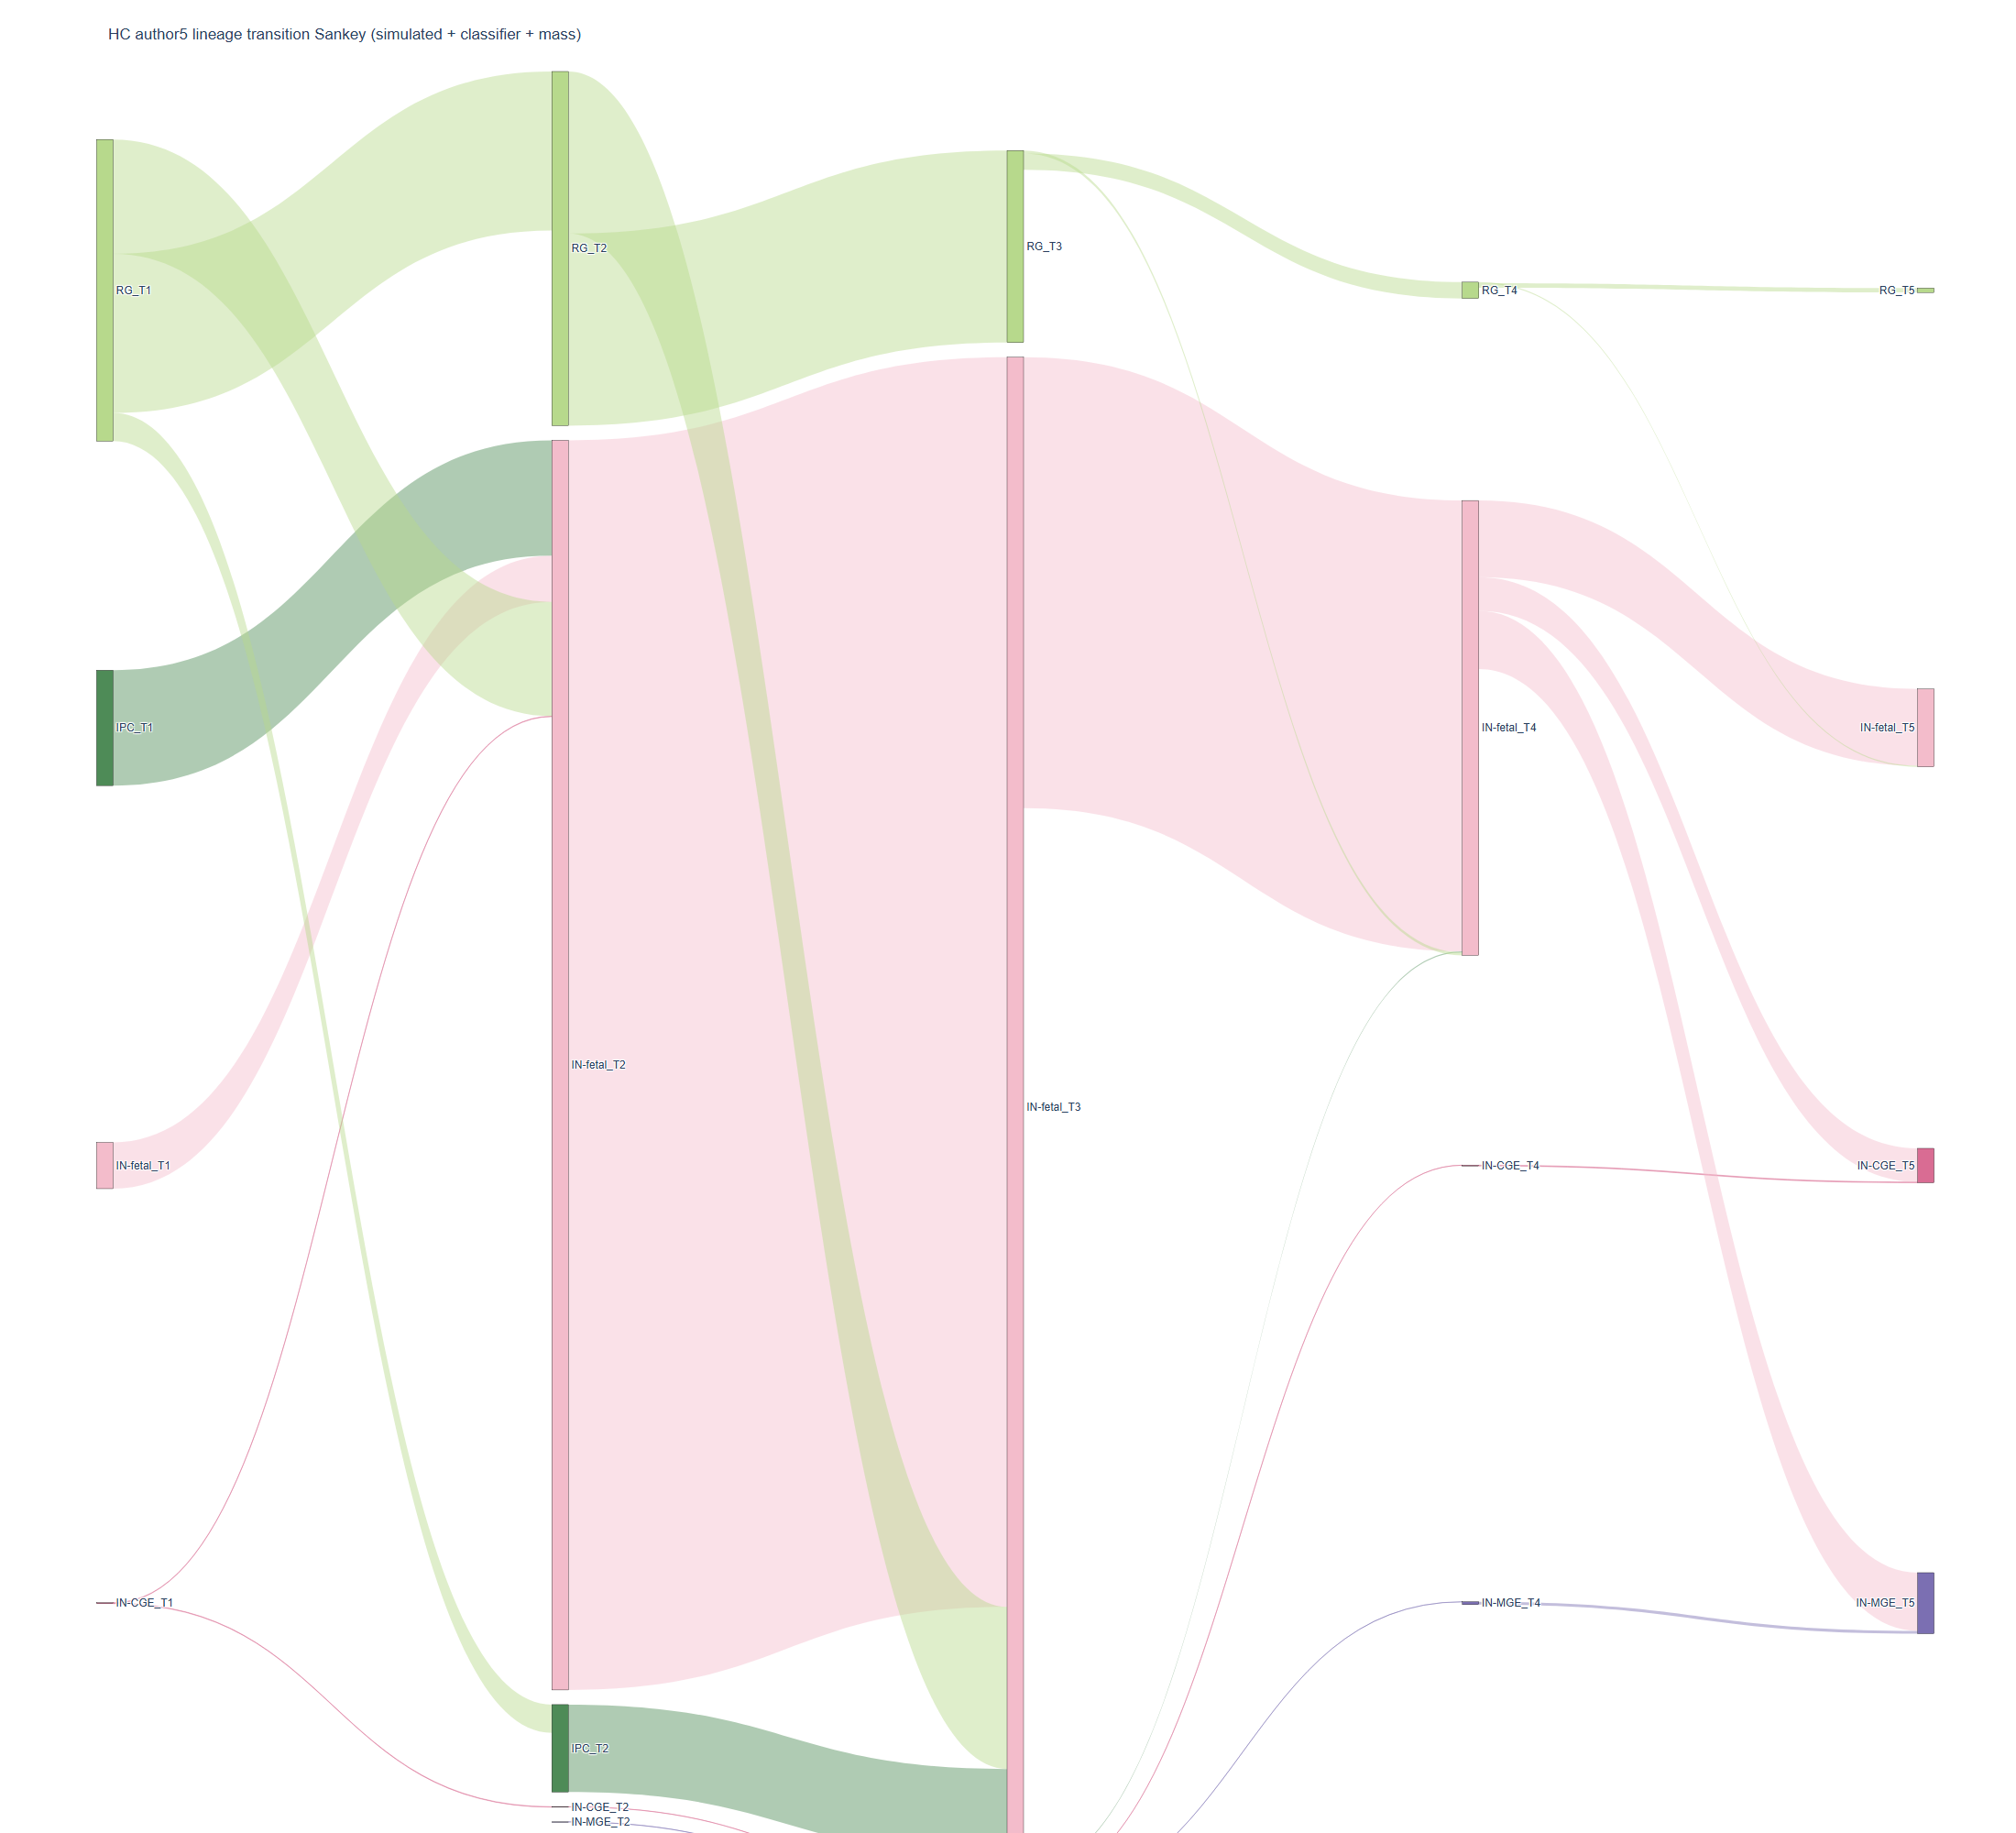

In [ ]:
from mofi_notebook import show_paper_panel
show_paper_panel(run_dir / "figures" / "author5_lineage" / "author5_lineage_sankey.png")


## 4. Prepare the ERBB4 perturbation

The context reuses the same fitted model and mapping for every perturbation score. Source-cell indices and target genes are explicit inputs and can be replaced without editing library code.


In [ ]:
import shutil
from CytoBridge.pl.tf.context import TFRunContext

ctx = TFRunContext.from_run_dir(run_dir)
trajectory_index_csv = ROOT / "configs" / "analysis_inputs" / "hc_erbb4_paper6_indices.csv"
fate_index_csv = ROOT / "configs" / "analysis_inputs" / "hc_erbb4_indices.csv"
erbb4_dir = run_dir / "figures" / "tf" / "erbb4"
trajectory_dir = erbb4_dir / "trajectory"
trajectory_dir.mkdir(parents=True, exist_ok=True)

shutil.copy2(
    ROOT / "paper_data" / "umap" / DATASET / "erbb4_primary.pkl",
    trajectory_dir / "umap_model_primary.pkl",
)
shutil.copy2(
    ROOT / "paper_data" / "umap" / DATASET / "erbb4_secondary.pkl",
    trajectory_dir / "umap_model_secondary.pkl",
)


## 5. Compare ERBB4 perturbation trajectories

Seven scores are simulated in both modalities. The cells below display the unperturbed and strongest positive conditions; all intermediate scores remain available in the same output directory.


In [ ]:
from CytoBridge.pl.tf.perturb import plot_perturbation_trajectories

with suppress_live_plot_output():
    trajectories = plot_perturbation_trajectories(
        ctx,
        indices_csv=str(trajectory_index_csv),
        scores=[-9, -6, -3, 0, 3, 6, 9],
        sample_n=6,
        seed=4,
        device=DEVICE,
        output_dir=str(trajectory_dir),
        dim_reduction="umap",
    )
trajectories


### RNA trajectories: unperturbed ERBB4


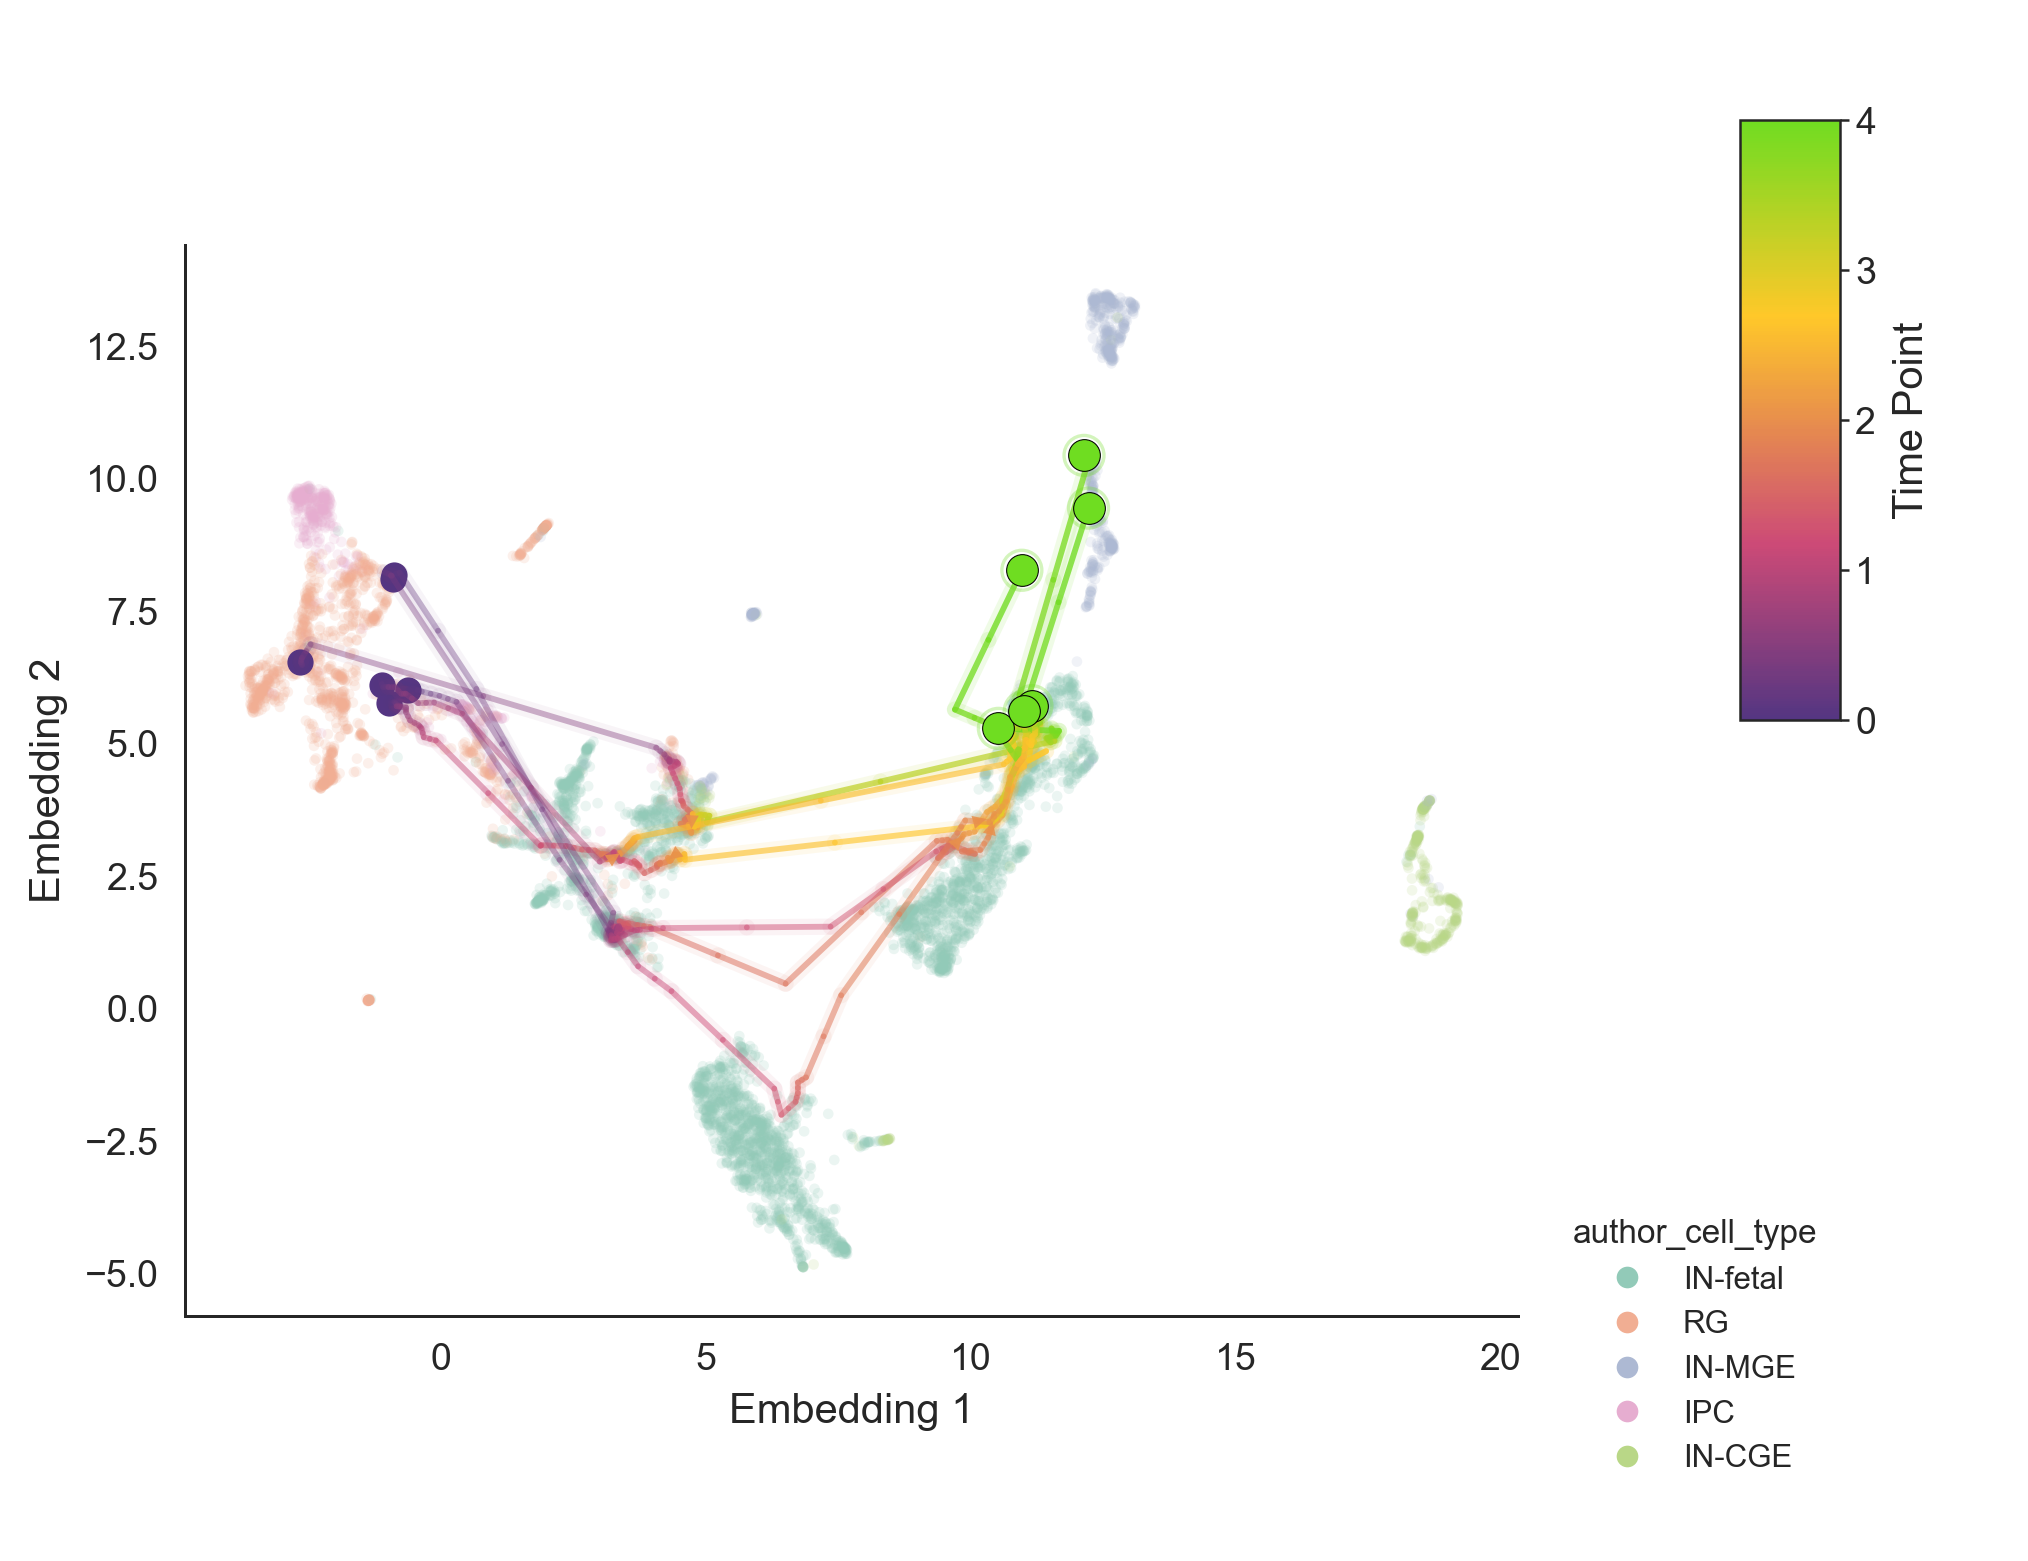

In [ ]:
from mofi_notebook import show_paper_panel
show_paper_panel(run_dir / "figures" / "tf" / "erbb4" / "trajectory" / "perturb_index_traj_primary__g-mge-erbb4__z-0__dr-umap.png")


### RNA trajectories: increased ERBB4


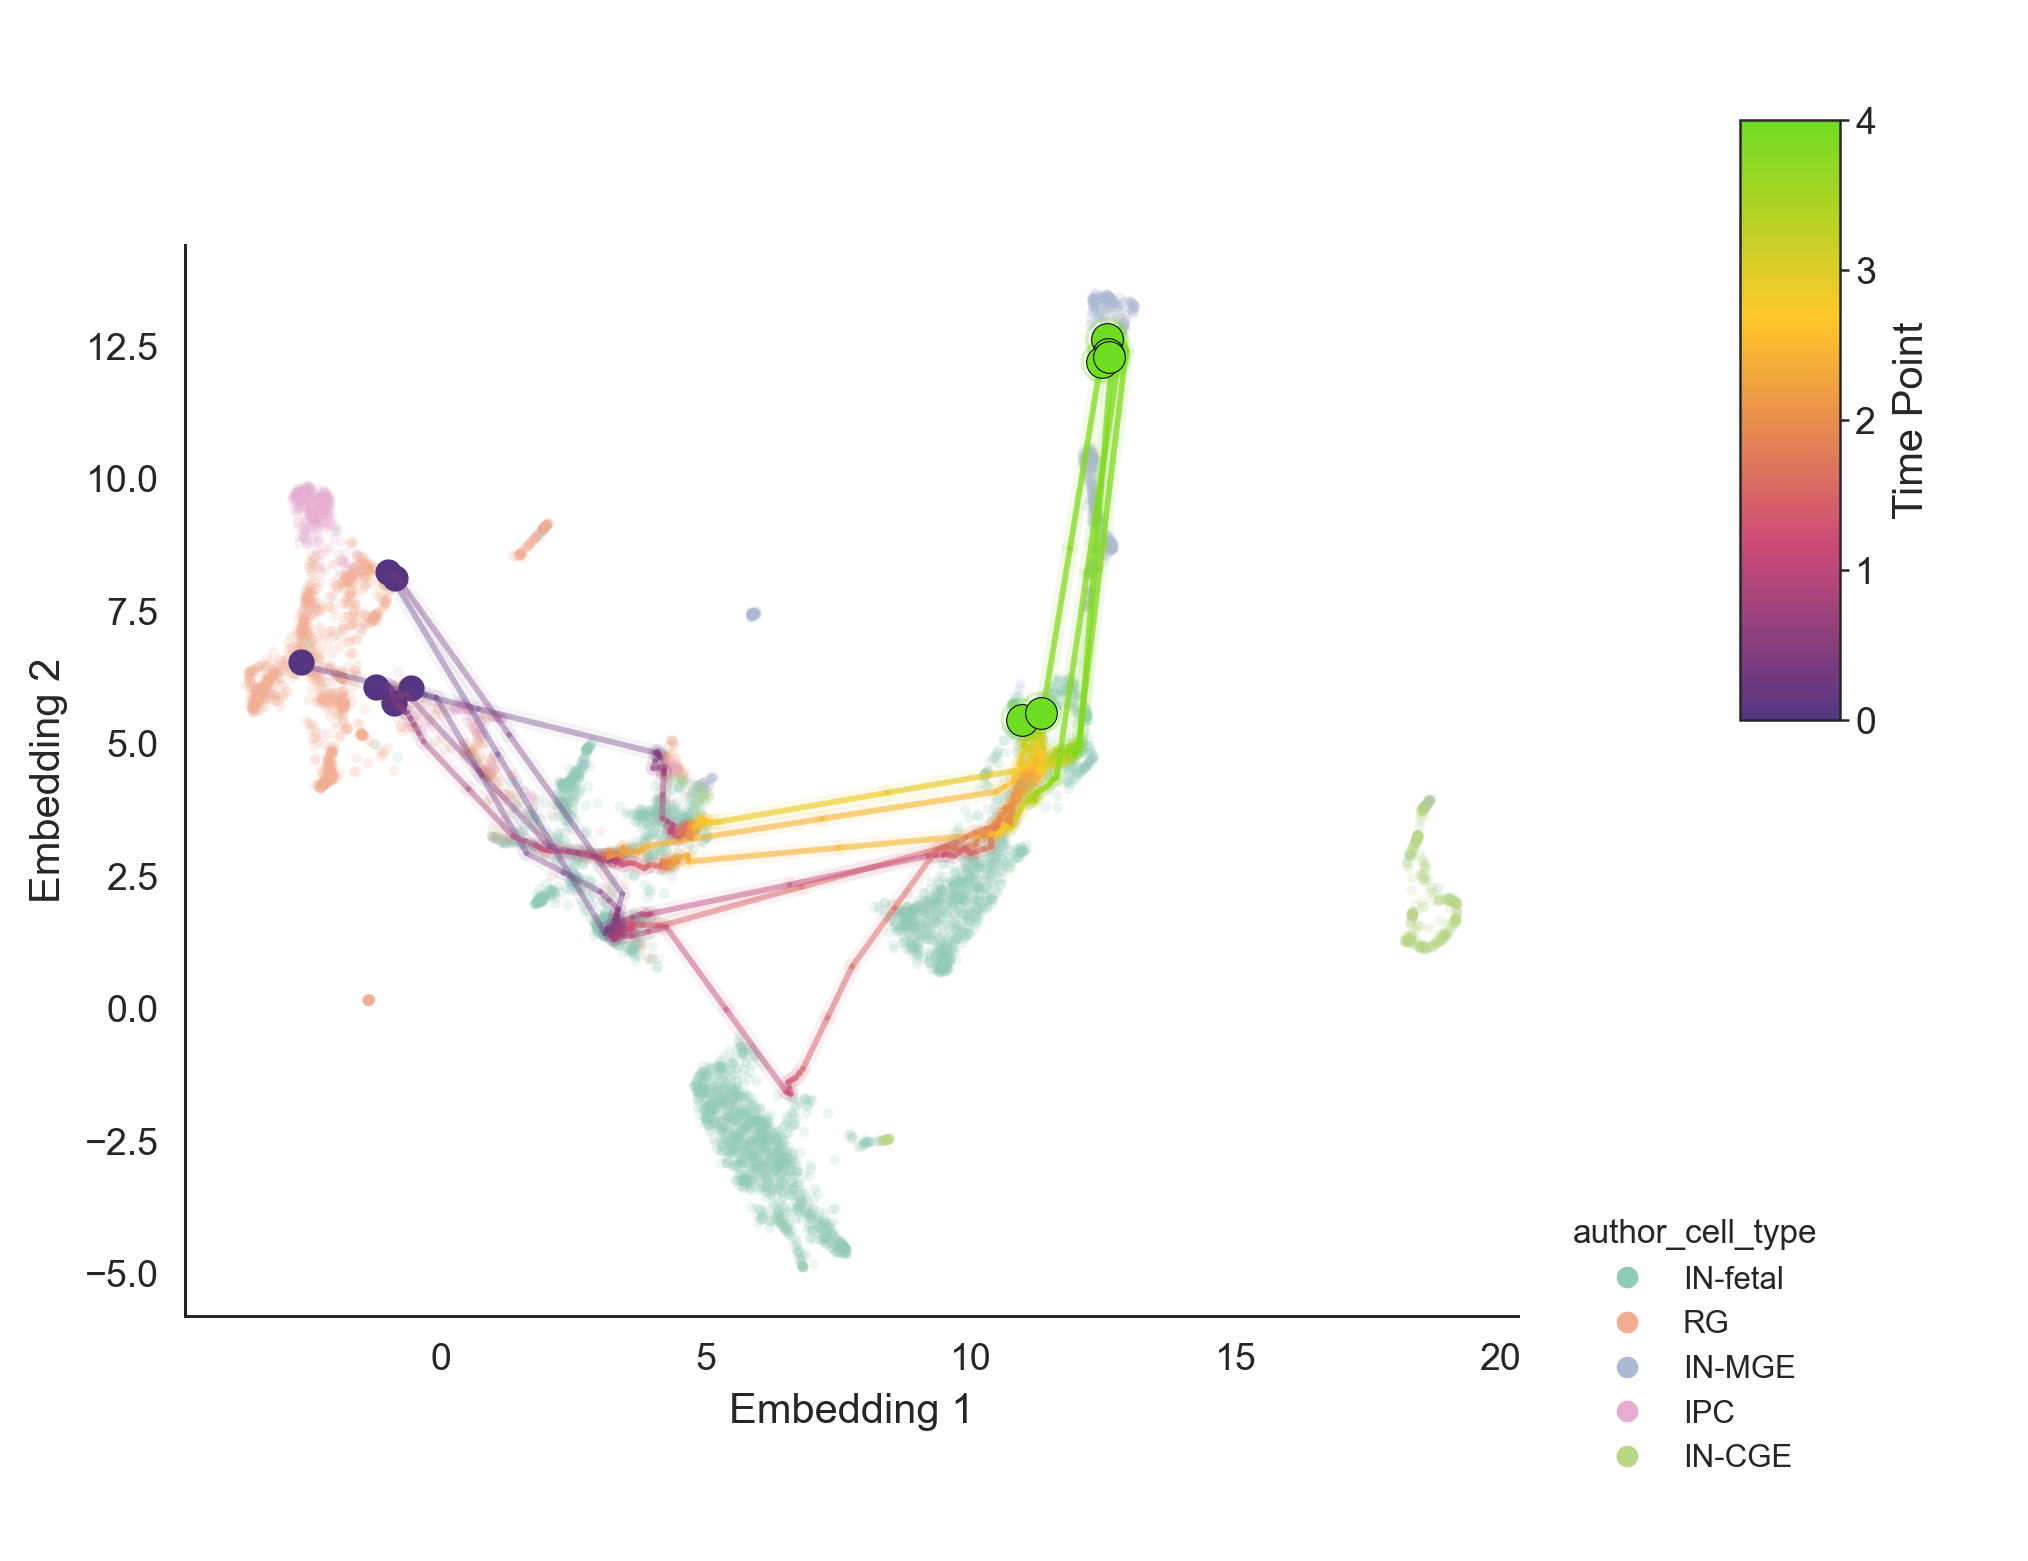

In [ ]:
from mofi_notebook import show_paper_panel
show_paper_panel(run_dir / "figures" / "tf" / "erbb4" / "trajectory" / "perturb_index_traj_primary__g-mge-erbb4__z-9__dr-umap.png")


### ATAC trajectories: unperturbed ERBB4


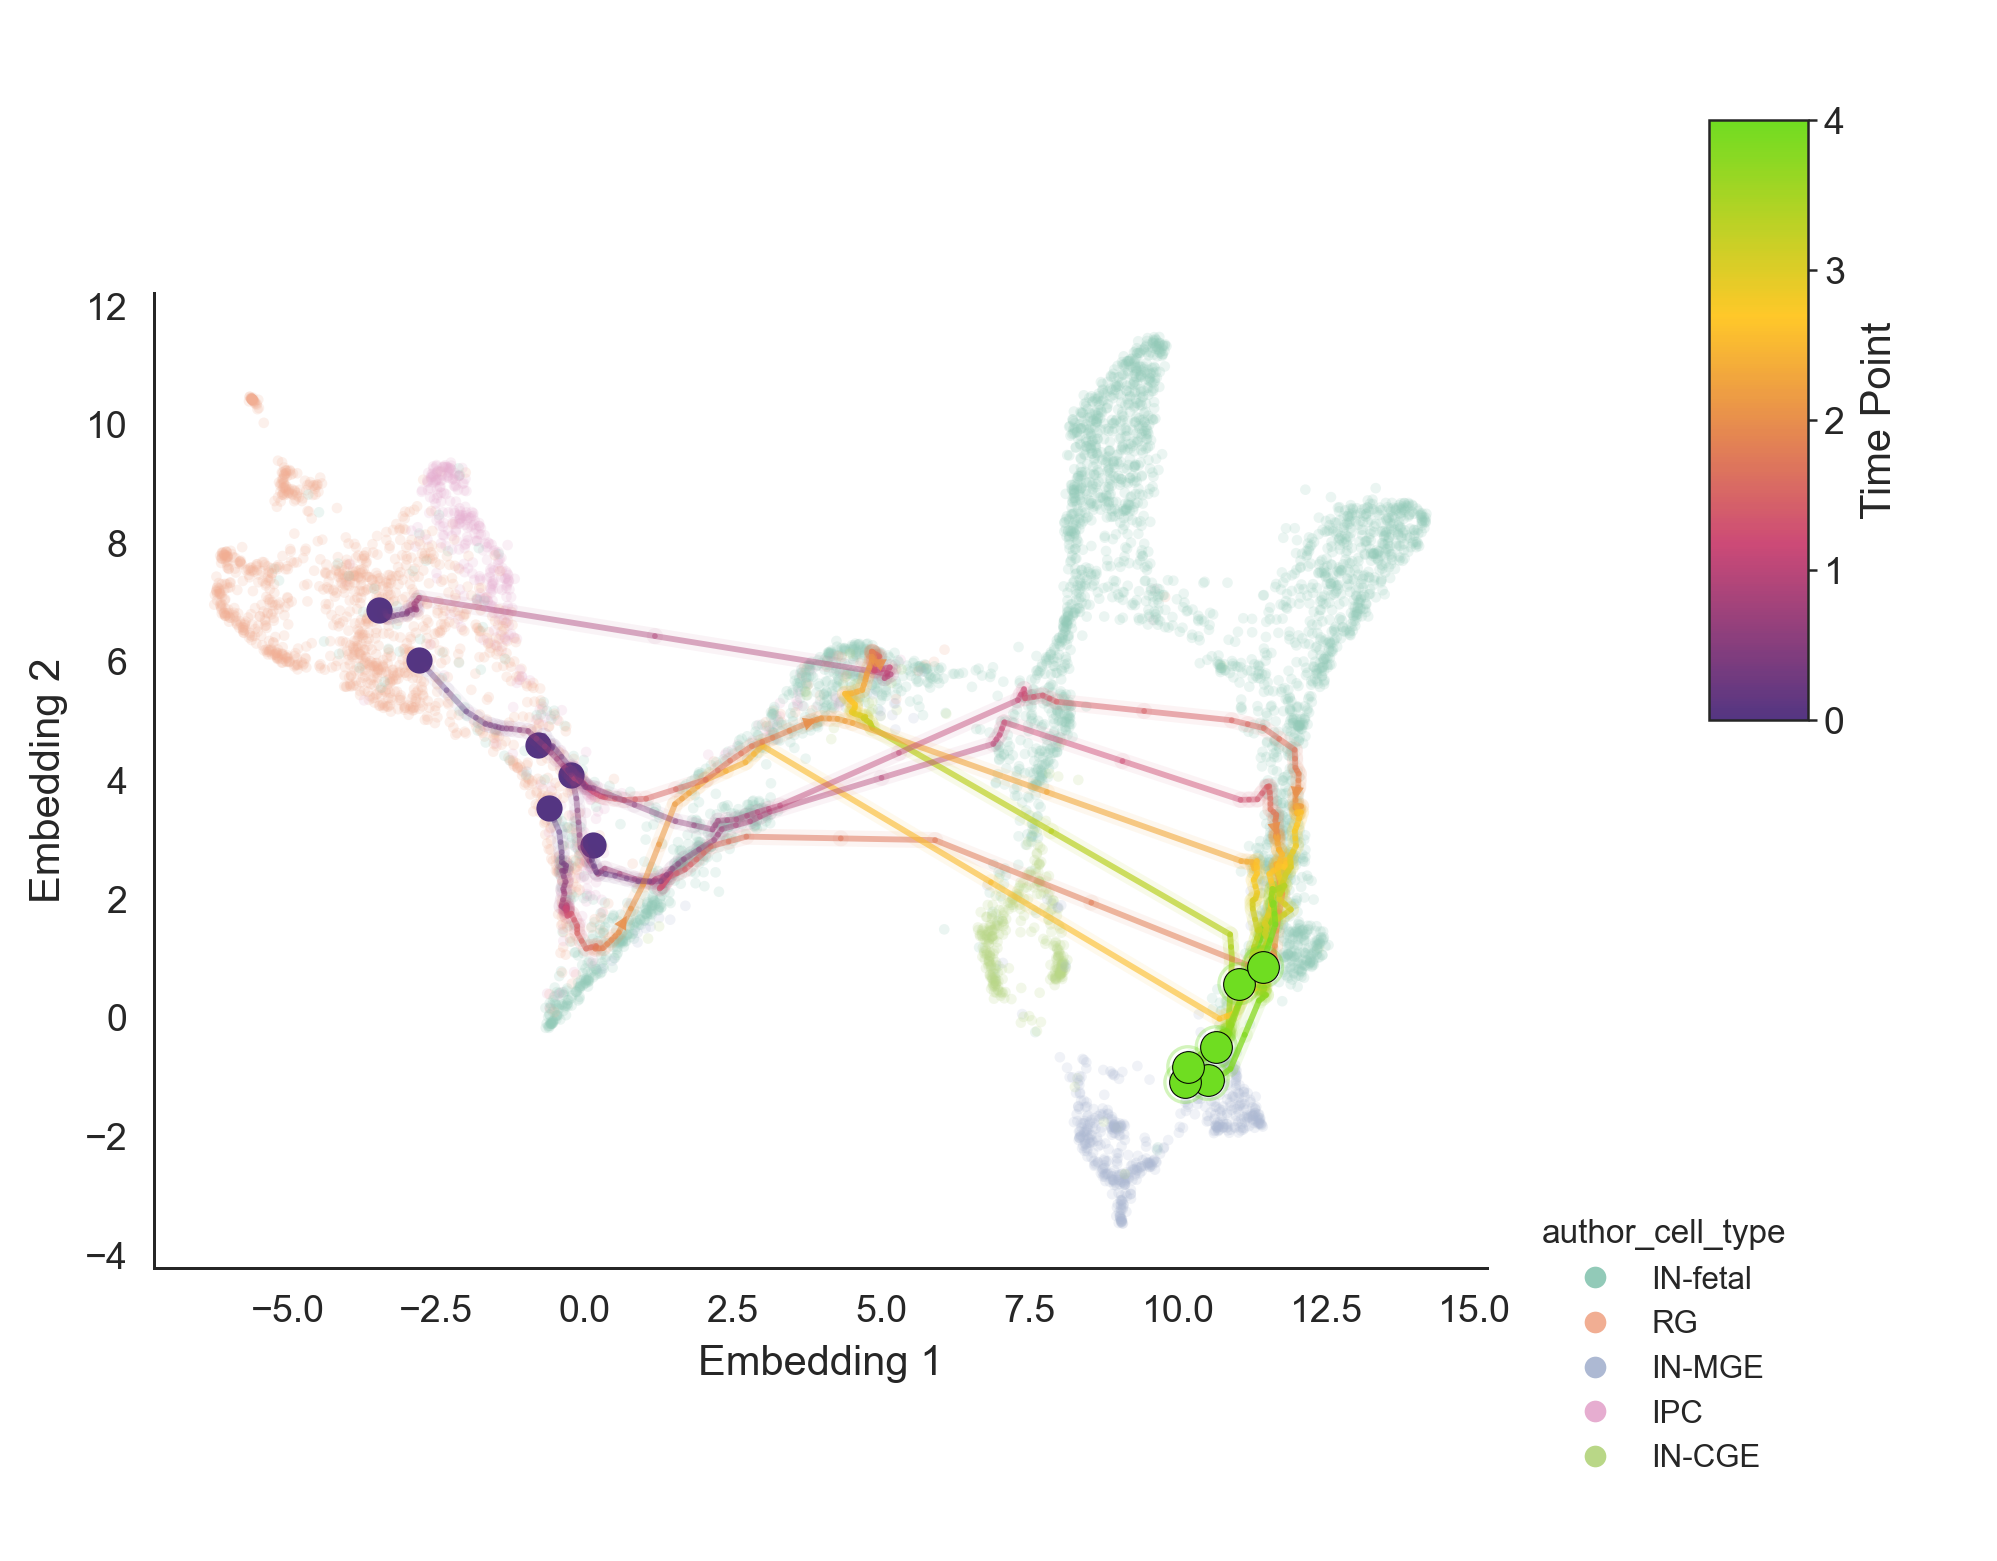

In [ ]:
from mofi_notebook import show_paper_panel
show_paper_panel(run_dir / "figures" / "tf" / "erbb4" / "trajectory" / "perturb_index_traj_secondary__g-mge-erbb4__z-0__dr-umap.png")


### ATAC trajectories: increased ERBB4


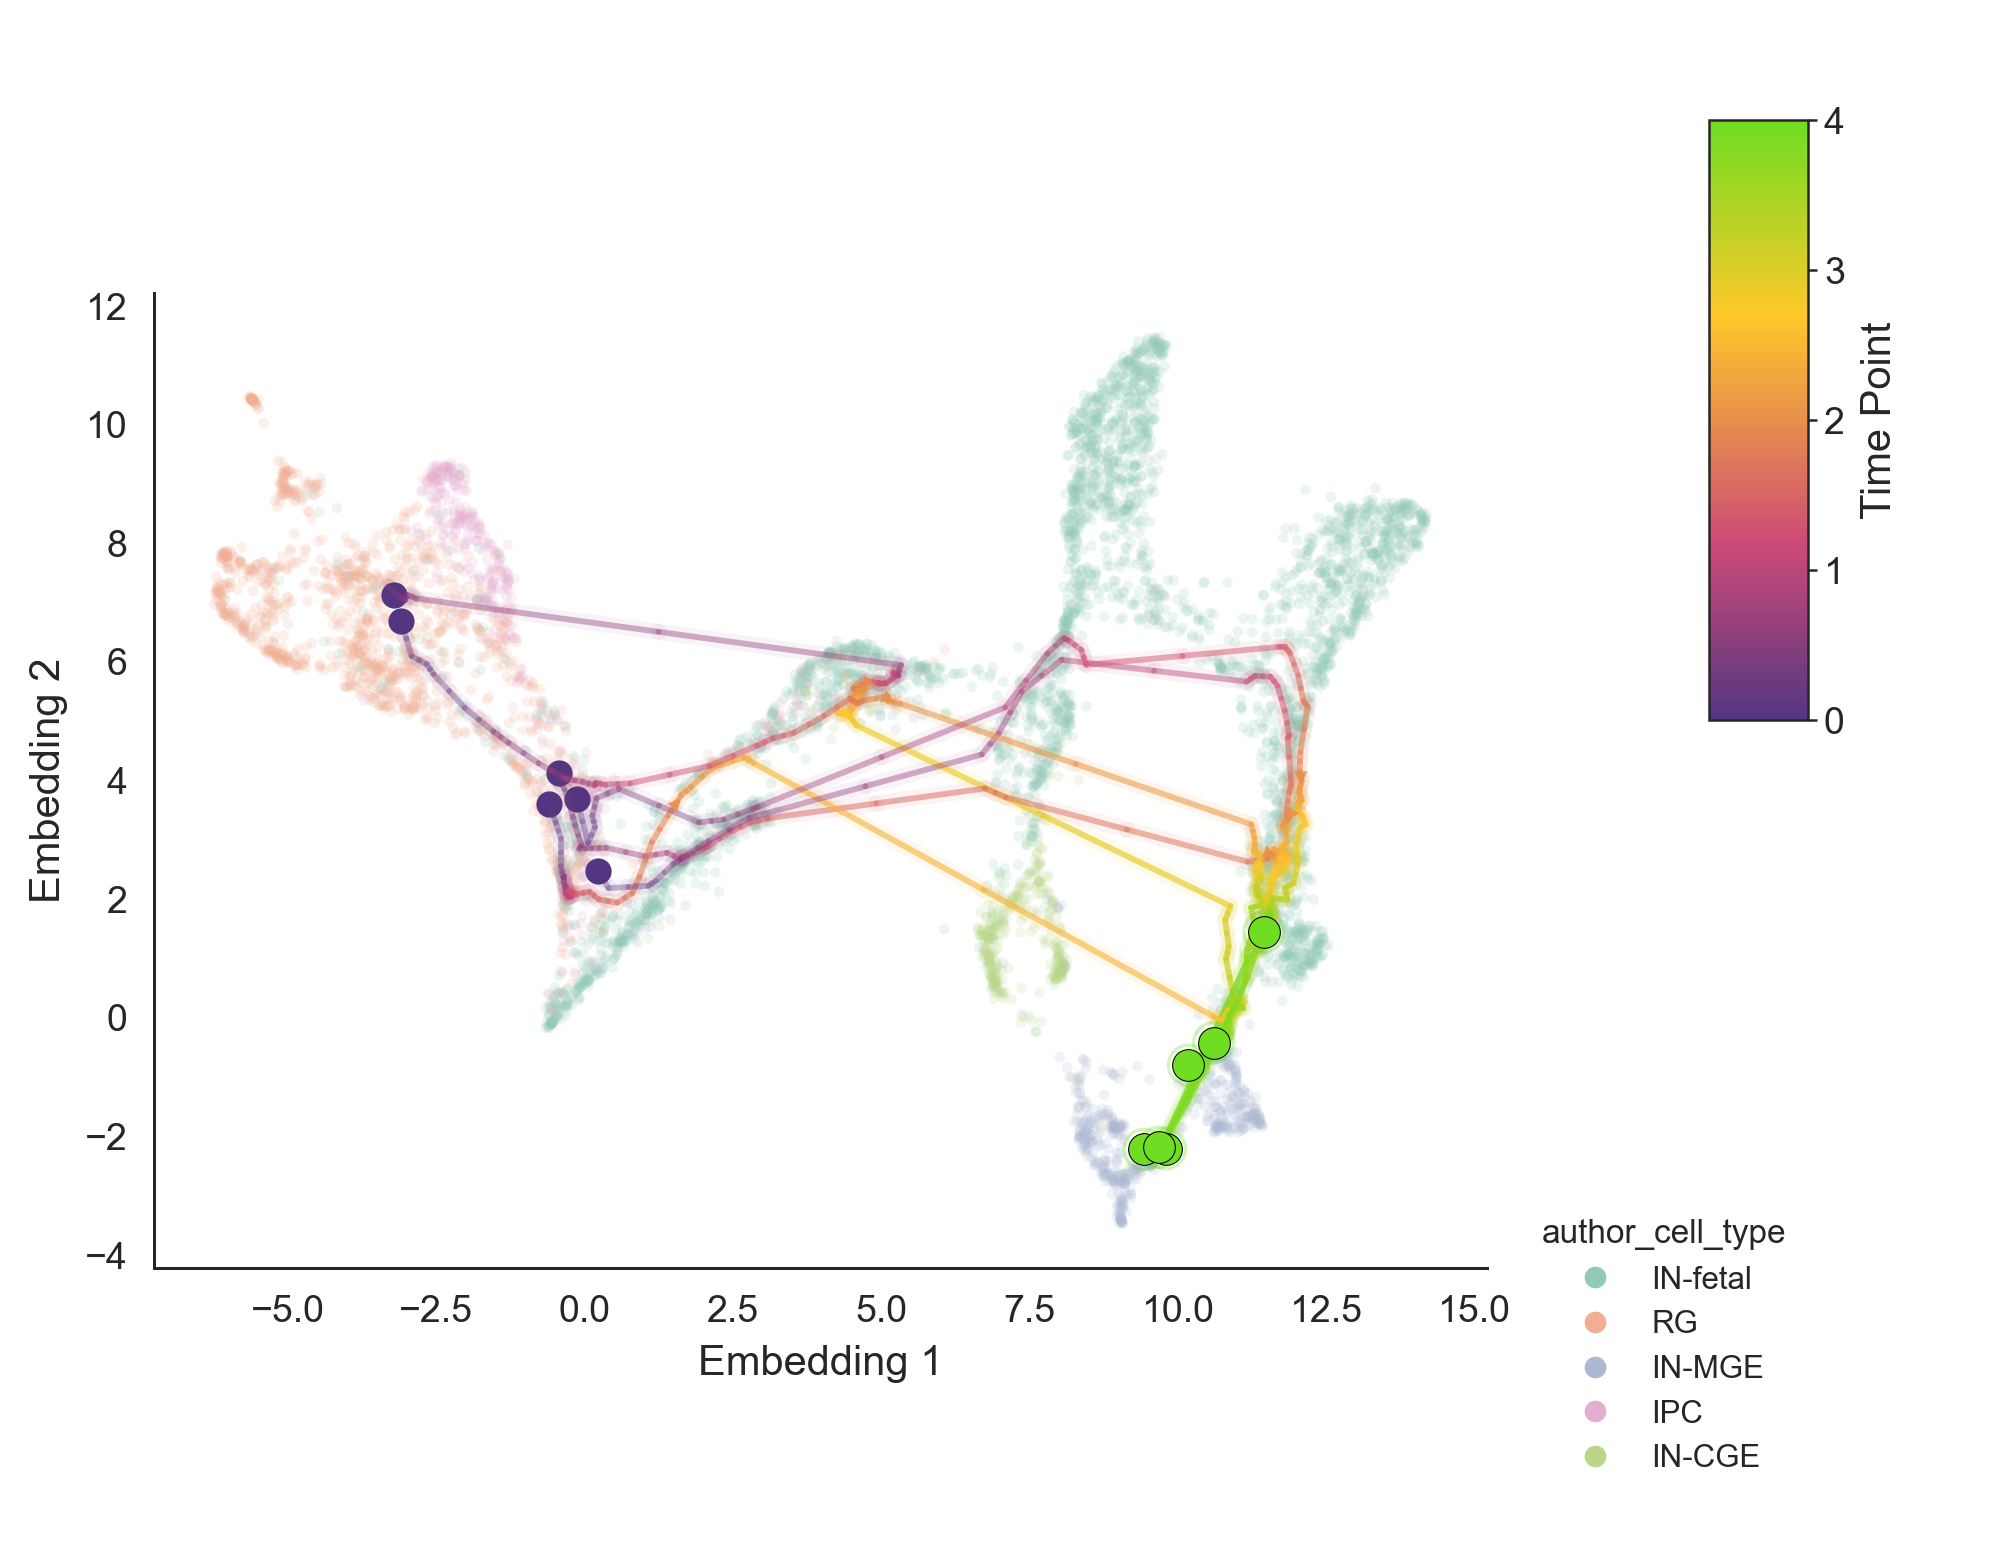

In [ ]:
from mofi_notebook import show_paper_panel
show_paper_panel(run_dir / "figures" / "tf" / "erbb4" / "trajectory" / "perturb_index_traj_secondary__g-mge-erbb4__z-9__dr-umap.png")


## 6. Summarize terminal fate composition

The heatmap compares predicted week-52 cell-type probabilities across perturbation scores. `sample_n='all'` uses every selected source cell, while the cell-type order controls only presentation.


In [ ]:
from CytoBridge.pl.tf.perturb import build_perturbation_fate_sweep

with suppress_live_plot_output():
    fate = build_perturbation_fate_sweep(
        ctx,
        indices_csv=str(fate_index_csv),
        target_group="mge_erbb4",
        target_genes=["ERBB4"],
        scores=[-9, -6, -3, 0, 3, 6, 9],
        sample_n="all",
        seed=4,
        device=DEVICE,
        output_table_dir=str(run_dir / "tables" / "tf" / "erbb4_fate"),
        output_figure_dir=str(erbb4_dir / "fate"),
        sweep_cell_types=["RG", "IPC", "IN-fetal", "IN-CGE", "IN-MGE"],
        focus_curve_cell_types=["RG", "IPC", "IN-fetal", "IN-CGE", "IN-MGE"],
        focus_curve_scores=[-9, -6, -3, 0, 3, 6, 9],
        heatmap_z_order=[-9, -6, -3, 0, 3, 6, 9],
        heatmap_orientation="z_by_cell_type",
        heatmap_cell_type_order=["IN-MGE", "IN-CGE", "IPC", "IN-fetal", "RG"],
        prob_heatmap_value_col="perturbed_prob",
    )
fate


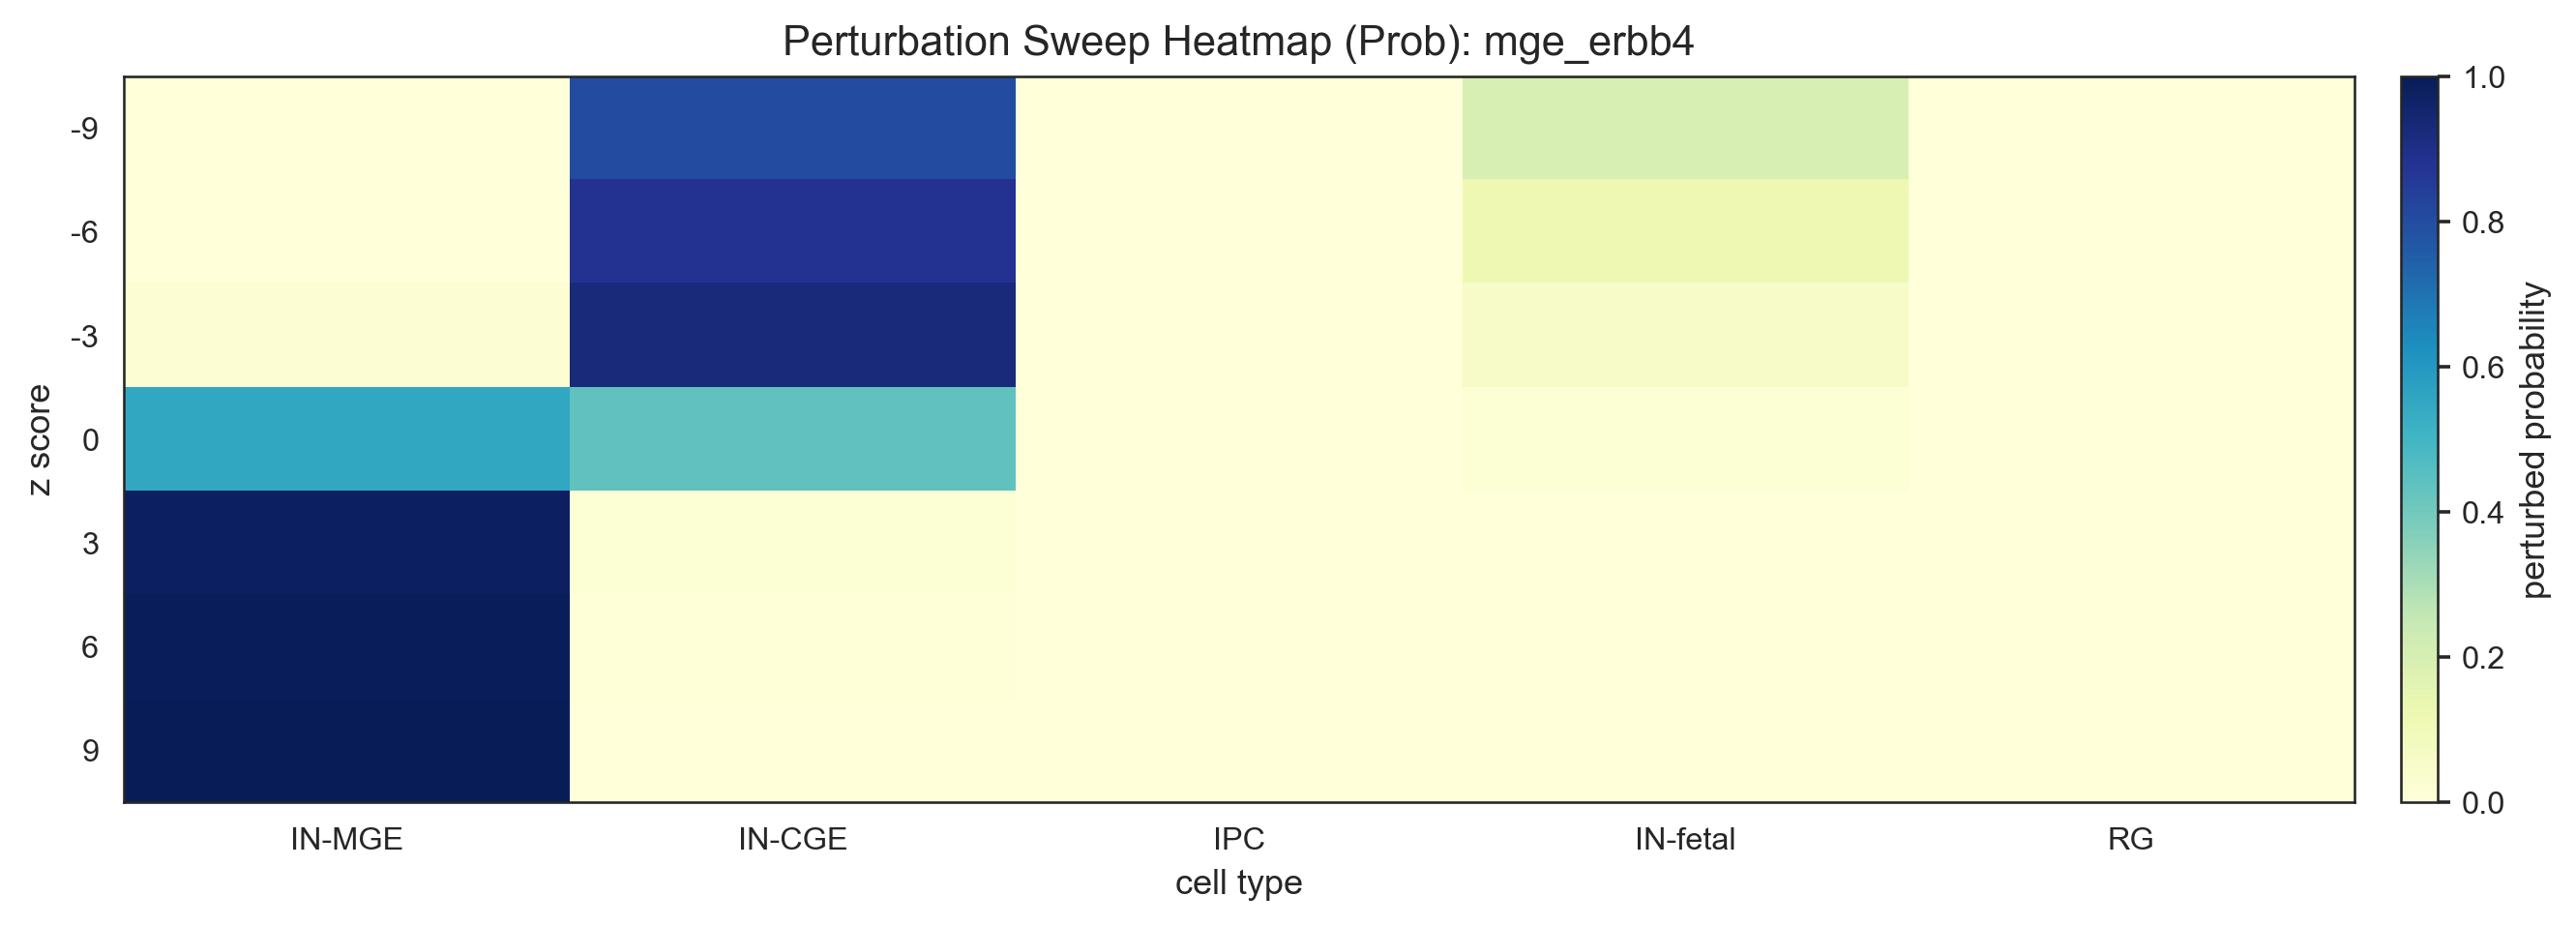

In [ ]:
from mofi_notebook import show_paper_panel
show_paper_panel(run_dir / "figures" / "tf" / "erbb4" / "fate" / "perturbation_sweep_heatmap_prob.png")


## Apply the workflow to your own data

The figure-specific helpers above keep the paper example concise, but the reusable workflow is the same for another RNA–ATAC dataset:

1. Put time labels and cell-type labels in `adata.obs`.
2. Preprocess each modality with `CytoBridge.pp.preprocess`.
3. Train the dynamics model with `CytoBridge.tl.fit` and save the returned `AnnData` object.
4. Fit or load the cross-modality map.
5. Reuse the plotting calls shown above with your own paths, marker names, perturbation targets, and time points.

```python
import scanpy as sc
import CytoBridge as cb

adata = sc.read_h5ad("my_data.h5ad")
adata = cb.pp.preprocess(
    adata,
    time_key="time",
    dim_reduction="PCA",
    normalization=True,
    log1p=True,
    select_hvg=True,
)
adata = cb.tl.fit(adata, config="ruot", device=DEVICE)
adata.write_h5ad("my_data_with_mofi_model.h5ad")
```

Start by changing only the input paths and metadata keys. Once that run works, change biological choices such as markers, source populations, perturbation scores, or displayed cell types.
